Classes available: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Low noise: noise=0.01, drift=0.005 -> Accuracy=75.10%
Medium noise: noise=0.03, drift=0.01 -> Accuracy=69.80%
High noise: noise=0.05, drift=0.02 -> Accuracy=63.90%


,Setting,Noise,Drift,Accuracy
0,Low noise,0.01,0.005,0.751
1,Medium noise,0.03,0.010,0.698
2,High noise,0.05,0.020,0.639


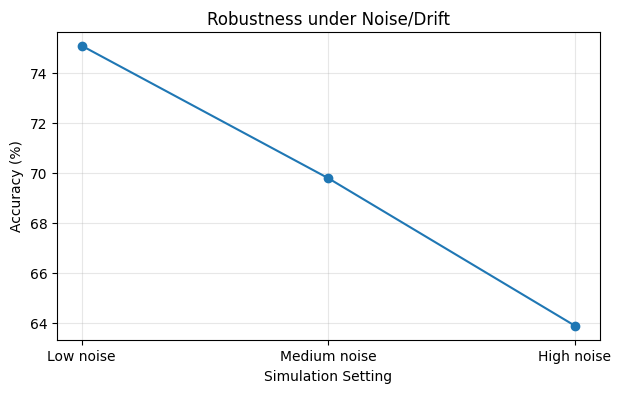


=== Medium noise classification report ===
              precision    recall  f1-score   support

           0      0.652     0.514     0.575       175
           1      0.500     0.320     0.390       150
           2      0.728     0.692     0.710       182
           3      0.823     0.688     0.749       176
           4      0.553     0.987     0.709       159
           5      0.963     0.987     0.975       158

    accuracy                          0.698      1000
   macro avg      0.703     0.698     0.685      1000
weighted avg      0.707     0.698     0.687      1000



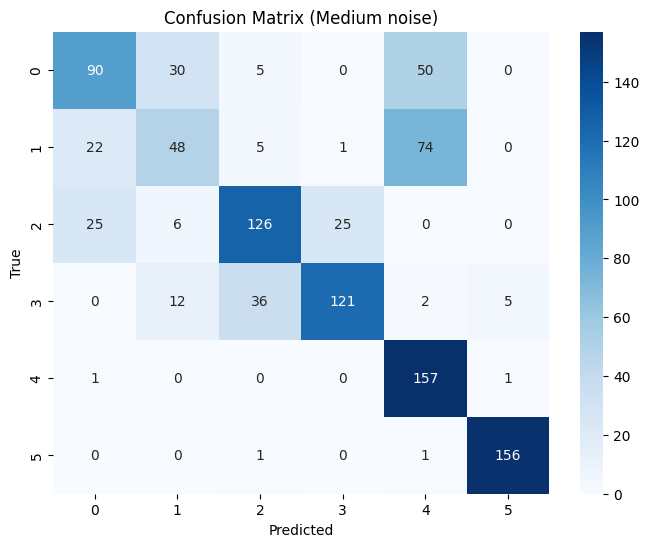

In [43]:
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Load model + scaler
# =========================
model = joblib.load("/content/Randomforest_model.joblib")
scaler = joblib.load("/content/my_scaler.joblib")

# =========================
# Load datasets (original)
# =========================
company_df = pd.read_csv("/content/company_data.csv")
kaggle_df  = pd.read_csv("/content/kaggle_dataset.csv")

features = ["Ia","Ib","Ic","Va","Vb","Vc"]

df = pd.concat([
    kaggle_df[features + ["Fault_Type"]],
    company_df[features + ["Fault_Type"]]
], ignore_index=True)

df = df.replace([np.inf, -np.inf], np.nan).dropna()
df["Fault_Type"] = df["Fault_Type"].astype(int)

# =========================
# Build per-class pool (Bootstrap source)
# =========================
class_pools = {}
for c in sorted(df["Fault_Type"].unique()):
    sub = df[df["Fault_Type"] == c][features].values
    if len(sub) >= 5:
        class_pools[c] = sub

print("Classes available:", list(class_pools.keys()))

# =========================
# Bootstrap Simulation (more realistic)
# =========================
def bootstrap_simulation(n_samples=1000, noise_level=0.01, drift_level=0.005, seed=42):
    rng = np.random.default_rng(seed)
    X_sim = []
    y_true = []

    classes = list(class_pools.keys())

    # slowly varying drift vector (applied gradually)
    drift_vec = np.zeros(len(features))

    for i in range(n_samples):
        c = rng.choice(classes)
        base = class_pools[c][rng.integers(0, len(class_pools[c]))].copy()

        # update drift slowly over time
        # drift changes a tiny bit each sample to simulate operating changes
        drift_step = drift_level * (rng.normal(0, 1, len(features)))
        drift_vec += drift_step

        # add noise proportional to magnitude (sensor noise)
        noise = rng.normal(0, noise_level * (np.abs(base) + 1e-6), len(features))
        sample = base + noise + drift_vec

        X_sim.append(sample)
        y_true.append(c)

    X_sim = np.array(X_sim)
    y_true = np.array(y_true)

    X_scaled = scaler.transform(X_sim)
    y_pred = model.predict(X_scaled)

    acc = accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred

# =========================
# Robustness Sweep
# =========================
settings = [
    ("Low noise",    0.01, 0.005),
    ("Medium noise", 0.03, 0.010),
    ("High noise",   0.05, 0.020),
]

results = []
saved = {}

for name, noise, drift in settings:
    acc, y_true, y_pred = bootstrap_simulation(
        n_samples=1000,
        noise_level=noise,
        drift_level=drift,
        seed=42
    )
    results.append([name, noise, drift, acc])
    saved[name] = (y_true, y_pred)
    print(f"{name}: noise={noise}, drift={drift} -> Accuracy={acc*100:.2f}%")

res_df = pd.DataFrame(results, columns=["Setting", "Noise", "Drift", "Accuracy"])
display(res_df)

# =========================
# Plot Accuracy vs setting
# =========================
plt.figure(figsize=(7,4))
plt.plot(res_df["Setting"], res_df["Accuracy"]*100, marker="o")
plt.ylabel("Accuracy (%)")
plt.xlabel("Simulation Setting")
plt.title("Robustness under Noise/Drift")
plt.grid(True, alpha=0.3)
plt.show()

# =========================
# Detailed report + confusion matrix for Medium noise
# =========================
y_true_m, y_pred_m = saved["Medium noise"]
print("\n=== Medium noise classification report ===")
print(classification_report(y_true_m, y_pred_m, digits=3))

cm = confusion_matrix(y_true_m, y_pred_m)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Medium noise)")
plt.show()